In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import seaborn as sns

In [ ]:
df= pd.read_csv('../housing.csv')

df.info()

df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

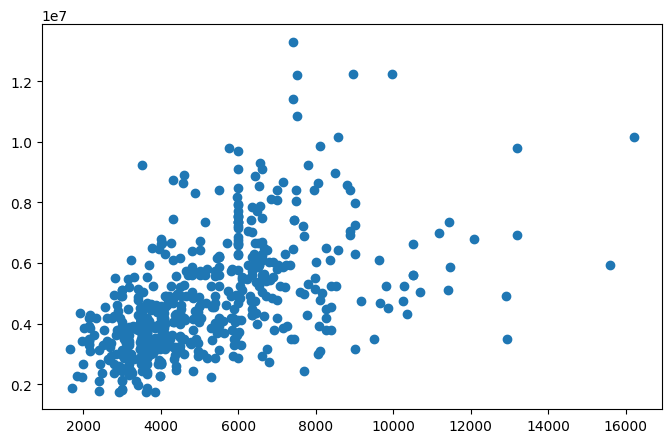

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['price'], df['area'])

In [16]:
def outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_price = outliers('price')
outliers_area = outliers('area')
print("Outliers in price:\n", outliers_price)
print('-' * 50)
print("Outliers in area:\n", outliers_area)
print(len(outliers_price), len(outliers_area))

Outliers in price:
        price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0   13300000   7420         4          2        3      yes        no       no   
1   12250000   8960         4          4        4      yes        no       no   
2   12250000   9960         3          2        2      yes        no      yes   
3   12215000   7500         4          2        2      yes        no      yes   
4   11410000   7420         4          1        2      yes       yes      yes   
5   10850000   7500         3          3        1      yes        no      yes   
6   10150000   8580         4          3        4      yes        no       no   
7   10150000  16200         5          3        2      yes        no       no   
8    9870000   8100         4          1        2      yes       yes      yes   
9    9800000   5750         3          2        4      yes       yes       no   
10   9800000  13200         3          1        2      yes        no      yes   
11   968

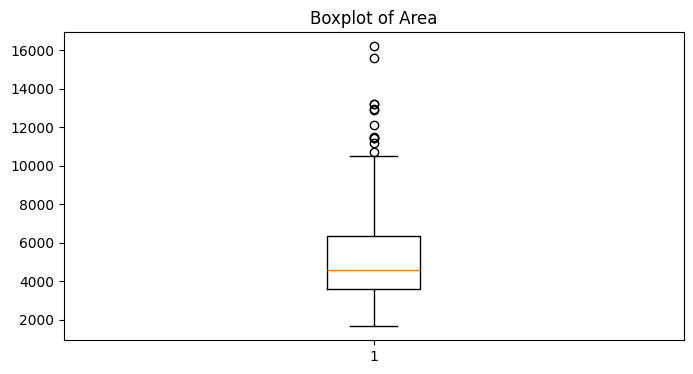

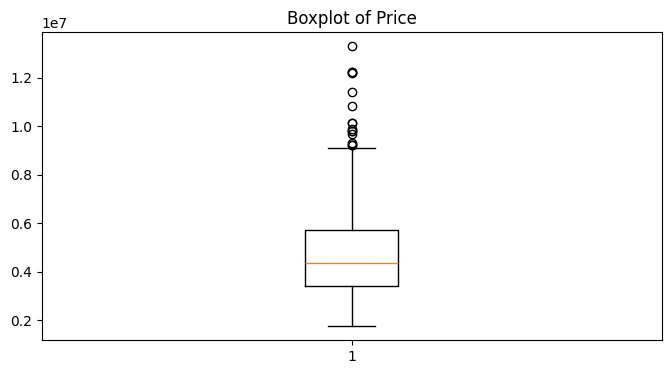

In [19]:
# Boxplot for area
plt.figure(figsize=(8, 4))
plt.boxplot(x=df['area'])
plt.title('Boxplot of Area')
plt.show()

# Boxplot for price
plt.figure(figsize=(8, 4))
plt.boxplot(x=df['price'])
plt.title('Boxplot of Price')
plt.show()


In [ ]:
x = df['area'].values.reshape(-1, 1)
y = df['price'].values

In [116]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
type(x_test)

numpy.ndarray

In [134]:
x_mean = np.mean(x_train)
y_mean = np.mean(y_train)
type(y)

numpy.ndarray

In [141]:
m = (np.sum((x_train-x_mean)*(y_train-y_mean))/np.sum((x_train-x_mean)**2))
m

np.float64(-25.148762220952097)

In [150]:
b = y_mean - m*x_mean
b

np.float64(4836147.7396886675)

In [ ]:
y_ = m * x_test + b
x_test.reshape(-1, 1)

array([[ 5900],
       [ 6500],
       [ 4040],
       [ 5000],
       [ 3960],
       [ 6720],
       [ 8520],
       [ 4990],
       [ 3240],
       [ 2700],
       [ 8580],
       [ 3934],
       [ 3720],
       [ 3100],
       [ 3970],
       [ 3630],
       [ 2000],
       [ 6000],
       [ 5850],
       [ 6000],
       [ 5020],
       [ 6825],
       [ 3649],
       [ 3800],
       [ 8250],
       [ 9960],
       [ 3090],
       [ 3000],
       [13200],
       [ 3000],
       [ 4000],
       [ 3120],
       [ 6000],
       [ 6615],
       [ 4775],
       [ 4600],
       [ 4646],
       [ 3180],
       [ 3480],
       [ 2787],
       [ 7980],
       [ 3630],
       [ 6420],
       [ 4200],
       [ 6750],
       [ 5885],
       [ 6000],
       [ 4640],
       [ 8050],
       [ 3000],
       [ 7475],
       [ 3000],
       [ 7770],
       [ 4500],
       [ 3640],
       [ 2910],
       [ 5750],
       [ 2400],
       [ 6450],
       [ 3800],
       [ 3180],
       [ 2135],
       [

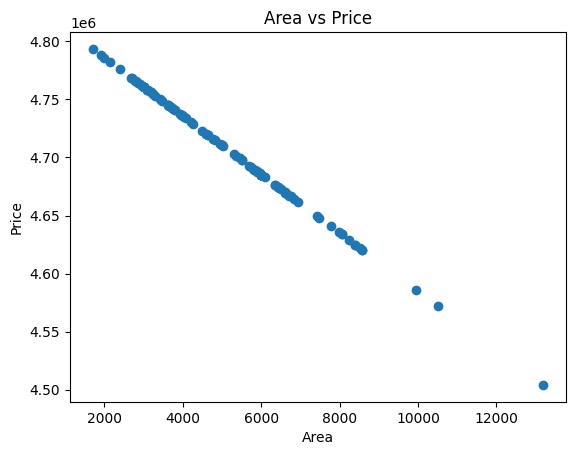

In [158]:
plt.scatter(x_test, y_)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

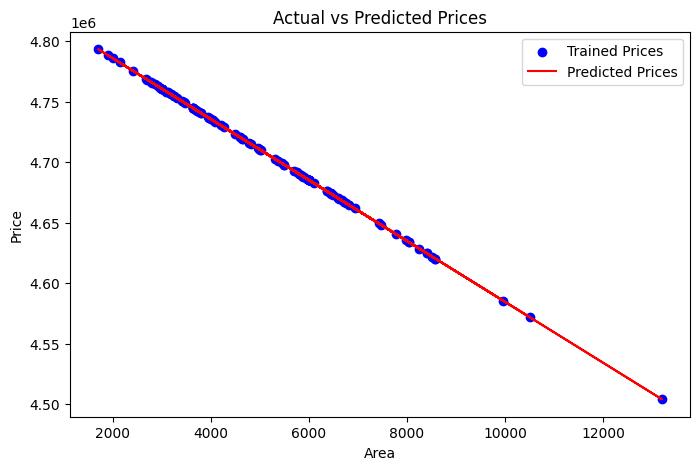

In [139]:
linear = LinearRegression()

linear.fit(x_train, y_train)


y_pred = linear.predict(x_test)


plt.figure(figsize=(8, 5))
# plt.scatter(df['area'], df['price'], color='green', label='Actual Prices')
plt.scatter(x_test, y_test, color='blue', label='Trained Prices')
plt.plot(x_test, y_pred, color='red', label='Predicted Prices')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()


In [131]:
mae = mean_absolute_error(y_test, y_pred)
mae

5.126546282287038e-11

In [120]:
mse = mean_squared_error(y_test, y_pred)
mse

4.774468282504974e-20

In [122]:
r2 = r2_score(y_test, y_pred)
r2

1.0

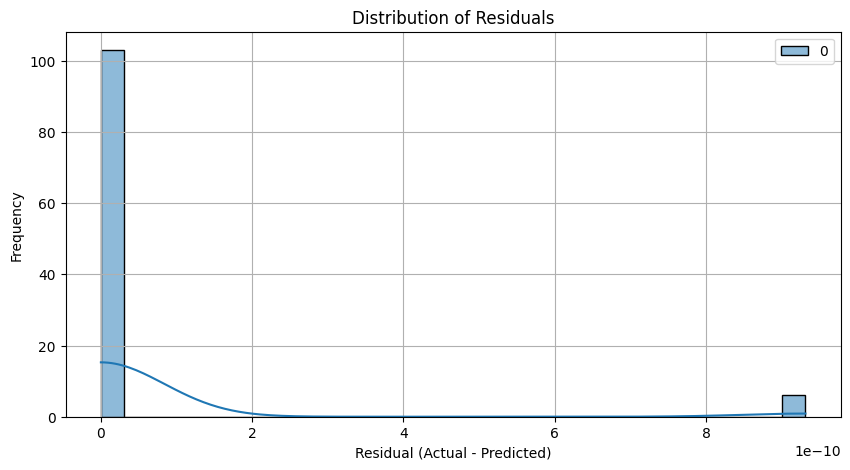

In [165]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



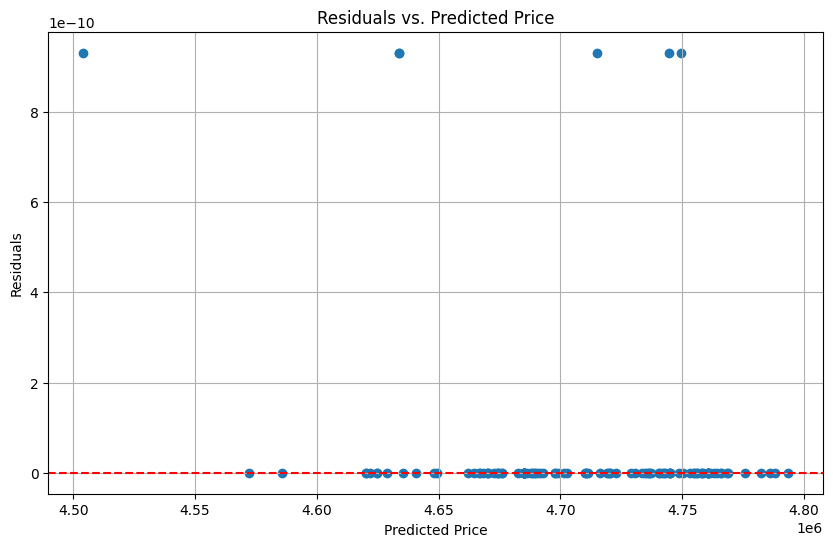

In [166]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Price')
plt.grid(True)
plt.show()


In [173]:
predicted_price = linear.predict([[1000]])
predicted_price

array([[4810998.97746772]])

In [174]:
df[['area', 'price']].describe()

,area,price
count,545.000000,5.450000e+02
mean,5150.541284,4.766729e+06
std,2170.141023,1.870440e+06
min,1650.000000,1.750000e+06
25%,3600.000000,3.430000e+06
50%,4600.000000,4.340000e+06
75%,6360.000000,5.740000e+06
max,16200.000000,1.330000e+07
